***Path Construction***
---

FUNCTION Construct_Path(parent, goal):

    path ← [goal]
    current ← goal

    WHILE parent[current] is not NONE:

        current ← parent[current]

        Add current to the beginning of path

    RETURN path

***A_Star Search Pseudocode***
---
FUNCTION A_Star(start, goal, graph, heuristic):

    Create an empty list called waiting_nodes
    Add start to waiting_nodes

    travelled_cost[start] ← 0
    parent[start] ← NONE

    Set travelled_cost of all other nodes to infinity

    WHILE waiting_nodes is not empty:

        Select the node from waiting_nodes having
        the smallest:

        travelled_cost[node] + heuristic[node]

        current ← selected node

        IF current = goal:

            path ← Construct_Path(parent, goal)

            PRINT travelled_cost[goal]

            RETURN path

        Remove current from waiting_nodes

        FOR each neighbor of current:

            new_cost ← travelled_cost[current]
                       + distance(current, neighbor)

            IF new_cost < travelled_cost[neighbor]:

                travelled_cost[neighbor] ← new_cost

                parent[neighbor] ← current

                IF neighbor is not in waiting_nodes:
                    Add neighbor to waiting_nodes

    RETURN "No path found"

# ***GBFS Pseudocode***

FUNCTION Greedy_Best_First_Search
         (start, goal, graph, heuristic):

    Create a waiting list
    Add the start node with its heuristic value

    Create an empty parent list

    Set the travelled cost of every node to infinity
    Set the travelled cost of the start node to 0

    WHILE the waiting list is not empty:

        Select the node having the smallest heuristic value
        current ← selected node

        IF current is the goal:

            PRINT travelled cost of the goal

            Construct and RETURN the path
            using the parent list

        Remove current from the waiting list

        FOR each neighbor of current:

            new_cost ← travelled cost of current
                       + distance to neighbor

            IF new_cost is smaller than
               the previous cost of neighbor:

                parent[neighbor] ← current

                travelled cost[neighbor] ← new_cost

                Add neighbor to the waiting list
                using its heuristic value as priority

    RETURN "No path found"

# Graph

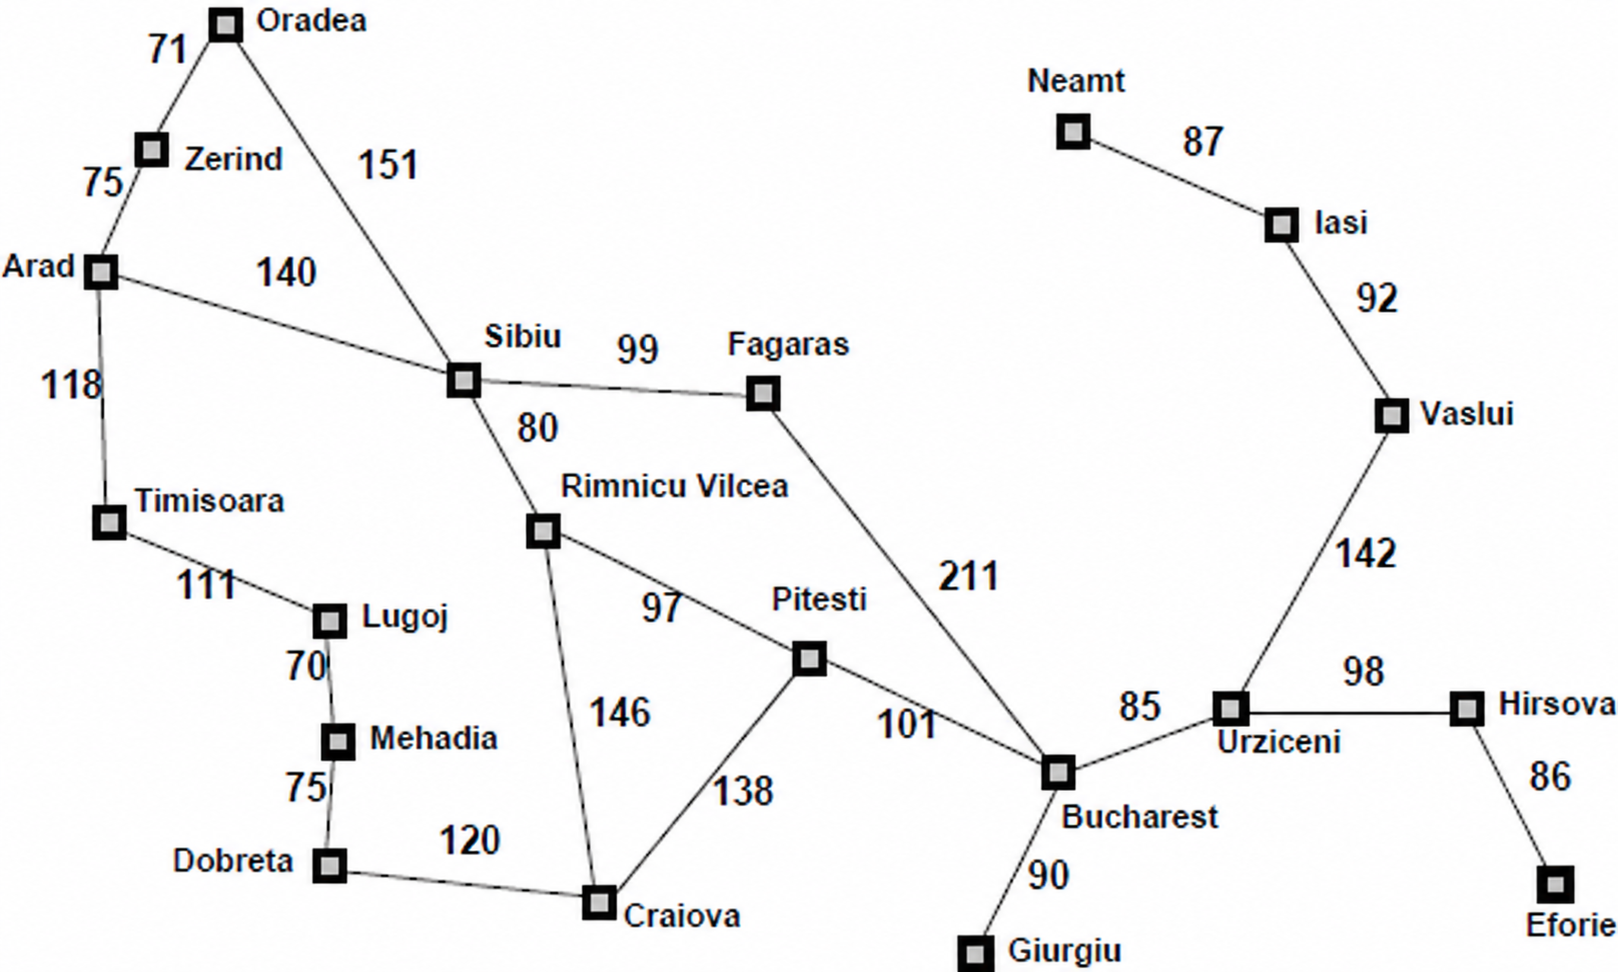

# A* Algorithm

In [ ]:
def reconstruct_path(came_from, current):
    path = [current]
    while current in came_from:
        current = came_from[current]
        path.insert(0, current)
    return path


def a_star_search(start, goal, graph, h):
    open_set = {start: h[start]}
    came_from = {}
    g_score = {city: float('inf') for city in graph.keys()}
    g_score[start] = 0

    while open_set:

        current = min(open_set, key=open_set.get)

        if current == goal:
            print("A* Total Cost:", g_score[current])
            return reconstruct_path(came_from, current)

        del open_set[current]


        for neighbor, dist in graph[current].items():
            tentative_g = g_score[current] + dist

            if tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                open_set[neighbor] = tentative_g + h[neighbor]

    return None


# GBFS

In [ ]:
def greedy_best_first_search(start, goal, graph, h):
    open_set = {start: h[start]}
    came_from = {}

    g_score = {city: float('inf') for city in graph.keys()}
    g_score[start] = 0

    while open_set:
        current = min(open_set, key=open_set.get)

        if current == goal:
            print("Greedy BFS Cost (g):", g_score[current])
            return reconstruct_path(came_from, current)

        del open_set[current]

        for neighbor, dist in graph[current].items():
            tentative_g = g_score[current] + dist
            if tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                open_set[neighbor] = h[neighbor]

    return None


# Taking Input a Graph

In [ ]:
# Heuristic values
h = {
    'Arad': 366,
    'Bucharest': 0,
    'Craiova': 160,
    'Drobeta': 242,
    'Eforie': 161,
    'Fagaras': 176,
    'Giurgiu': 77,
    'Hirsova': 151,
    'Iasi': 226,
    'Lugoj': 244,
    'Mehadia': 241,
    'Neamt': 234,
    'Oradea': 380,
    'Pitesti': 100,
    'Rimnicu Vilcea': 193,
    'Sibiu': 253,
    'Timisoara': 329,
    'Urziceni': 80,
    'Vaslui': 199,
    'Zerind': 374
}

# Graph representation
graph = {
    'Arad': {'Zerind':75, 'Sibiu':140, 'Timisoara':118},
    'Zerind': {'Arad':75, 'Oradea':71},
    'Oradea': {'Zerind':71, 'Sibiu':151},
    'Sibiu': {'Arad':140, 'Oradea':151, 'Fagaras':99, 'Rimnicu Vilcea':80},
    'Fagaras': {'Sibiu':99, 'Bucharest':211},
    'Rimnicu Vilcea': {'Sibiu':80, 'Pitesti':97, 'Craiova':146},
    'Pitesti': {'Rimnicu Vilcea':97, 'Craiova':138, 'Bucharest':101},
    'Timisoara': {'Arad':118, 'Lugoj':111},
    'Lugoj': {'Timisoara':111, 'Mehadia':70},
    'Mehadia': {'Lugoj':70, 'Drobeta':75},
    'Drobeta': {'Mehadia':75, 'Craiova':120},
    'Craiova': {'Drobeta':120, 'Rimnicu Vilcea':146, 'Pitesti':138},
    'Bucharest': {'Fagaras':211, 'Pitesti':101, 'Giurgiu':90, 'Urziceni':85},
    'Giurgiu': {'Bucharest':90},
    'Urziceni': {'Bucharest':85, 'Hirsova':98, 'Vaslui':142},
    'Hirsova': {'Urziceni':98, 'Eforie':86},
    'Eforie': {'Hirsova':86},
    'Vaslui': {'Urziceni':142, 'Iasi':92},
    'Iasi': {'Vaslui':92, 'Neamt':87},
    'Neamt': {'Iasi':87}
}

In [ ]:
# Run A*
path_a = a_star_search("Arad", "Bucharest", graph, h)
print("A* Path:", path_a)

A* Total Cost: 418
A* Path: ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']


In [ ]:
# Run Greedy Best-First Search
path_g = greedy_best_first_search("Arad", "Bucharest", graph, h)
print("Greedy BFS Path:", path_g)

Greedy BFS Cost (g): 450
Greedy BFS Path: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
